> **Optional advanced material.** This notebook is part of the *advanced,
> optional path* of this series — interpretability research aimed at data
> scientists and ML practitioners who want to look inside a real language
> model's internals. It goes well beyond what's needed for the main
> oilfield lessons and assumes comfort with Python, PyTorch tensors, and
> general deep-learning concepts.
>
> **You do not need this notebook** to get practical value from the main
> path — see `../notebooks/01_how_a_real_llm_predicts_the_next_token.ipynb`
> and `../notebooks/02_temperature_sampling_and_decoding_strategies.ipynb`,
> or the project [README](../README.md), for that.


# Probing Classifiers: Is Oilfield Operation Context Linearly Decodable Inside the Model?

**Notebook 6 of the series.** Every previous notebook asked questions about
the model's *own* output — its next-token distribution (1–2), its internal
attention and embeddings (3), and how much specific inputs causally
mattered to a specific prediction (4–5). This notebook asks a genuinely
different question, using a genuinely different kind of method: **is a
piece of information we define ourselves — the category of oilfield
operation a sentence describes — linearly readable out of the model's
internal representation at a given layer, regardless of what the model
itself was asked to predict?**

This technique is called **probing**: freeze the model, extract its
internal representations for a set of inputs, and train a small, separate
classifier on top of those frozen representations to predict an externally
defined label. Unlike every previous notebook, the "ground truth" here is
not the model's own prediction — it's a label *we* assign, by construction,
when we build the dataset below.

Still out of scope: circuit-level analysis of individual attention heads or
neurons. That is a further, more fine-grained step beyond what a
whole-layer linear probe can tell us.

## Learning objectives

1. What is a probing classifier, and how is its "ground truth" different
   from every previous notebook's target (the model's own prediction)?
2. Why does a probe's accuracy measure whether information is linearly
   *present* in a representation — not whether the model *uses* it?
3. Why is it important to test a probe on genuinely novel phrasing, not
   just held-out examples that may share exact wording with training data?
4. What does a real probe-accuracy-by-layer curve look like for an oilfield
   operation-category task, and where does it rise?
5. What can a probing classifier's result establish — and, just as
   important, what can it not establish about the model's own behavior?


## 1. What problem are we investigating?

Notebook 1 showed that "POOH" alone is ambiguous, and that the model's
*output* distribution shifts once you add operational context (drilling vs.
logging vs. fishing, etc.). That showed the model's behavior changes with
context. It did not show whether the category of operation is represented
as a clean, linearly-readable signal somewhere inside the network, or
whether it's tangled up with everything else in a way no simple classifier
could easily extract.

Probing answers a narrower, different question than notebooks 3–5 did:

- Attention (notebook 3) and activation patching (notebook 5) ask: *does
  this internal value matter for this specific prediction?*
- Probing asks: *is this externally defined property linearly present in
  this representation at all* — independent of whether the model's own
  next-token prediction ever depends on it?

A probe finding strong signal does **not** mean the model uses that signal
for its own behavior. Section 10 returns to this distinction directly, once
we have real results to discuss it against.


## Installation (run once)

This notebook adds one new dependency to the series: **scikit-learn**, for
training linear probing classifiers.


In [1]:
# Run this once. After the packages are installed you can leave this commented out.
# %pip install torch transformers accelerate pandas matplotlib numpy scikit-learn
print("If an import in the next cell fails, uncomment and run the pip install line above, then re-run this notebook.")


If an import in the next cell fails, uncomment and run the pip install line above, then re-run this notebook.


## 2. Load the real language model

Standard setup, matching notebooks 1–2 and 5 — no special
`attn_implementation` or forced `float32` is needed for this notebook.


In [2]:
import random
import time
import sys

import numpy as np
import pandas as pd
import torch
import transformers
import sklearn
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PRIMARY_MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
PRIMARY_MODEL_REVISION = "989aa7980e4cf806f80c7fef2b1adb7bc71aa306"  # pinned for reproducibility
FALLBACK_MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"  # used only if the primary model fails to load
FALLBACK_MODEL_REVISION = "7ae557604adf67be50417f59c2c2f167def9a775"  # pinned for reproducibility

if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

DTYPE = torch.float16 if DEVICE in ("mps", "cuda") else torch.float32

print(f"Python version:       {sys.version.split()[0]}")
print(f"PyTorch version:      {torch.__version__}")
print(f"Transformers version: {transformers.__version__}")
print(f"scikit-learn version: {sklearn.__version__}")
print(f"Selected device:      {DEVICE}")
print(f"Selected dtype:       {DTYPE}")


Python version:       3.12.13
PyTorch version:      2.14.0
Transformers version: 5.16.1
scikit-learn version: 1.9.0
Selected device:      mps
Selected dtype:       torch.float16


In [3]:
def load_model(model_name: str = PRIMARY_MODEL_NAME):
    '''Load a causal language model and its tokenizer onto the selected device.

    Falls back to FALLBACK_MODEL_NAME if the primary model cannot be loaded,
    and always reports which model actually ended up running.
    '''
    try:
        tok = AutoTokenizer.from_pretrained(model_name, revision=PRIMARY_MODEL_REVISION)
        mdl = AutoModelForCausalLM.from_pretrained(model_name, revision=PRIMARY_MODEL_REVISION, dtype=DTYPE, use_safetensors=True)
        mdl.to(DEVICE)
        mdl.eval()
        return tok, mdl, model_name
    except Exception as exc:  # noqa: BLE001 - report and fall back, don't crash the notebook
        print(f"Could not load '{model_name}' ({exc}). Falling back to '{FALLBACK_MODEL_NAME}'.")
        tok = AutoTokenizer.from_pretrained(FALLBACK_MODEL_NAME, revision=FALLBACK_MODEL_REVISION)
        mdl = AutoModelForCausalLM.from_pretrained(FALLBACK_MODEL_NAME, revision=FALLBACK_MODEL_REVISION, dtype=DTYPE, use_safetensors=True)
        mdl.to(DEVICE)
        mdl.eval()
        return tok, mdl, FALLBACK_MODEL_NAME


tokenizer, model, MODEL_NAME = load_model()
embedding_layer = model.get_input_embeddings()
NUM_LAYERS = model.config.num_hidden_layers
print(f"\nModel actually loaded and used in this notebook: {MODEL_NAME}")
print(f"Transformer layers: {NUM_LAYERS}")



Model actually loaded and used in this notebook: Qwen/Qwen2.5-1.5B-Instruct
Transformer layers: 28


## 3. Building a labeled oilfield dataset

Every earlier notebook's "ground truth" was the model's own top-predicted
token. Probing needs something different: a label **we** assign ourselves,
independent of the model. We build one here from realistic oilfield
sentence templates: five operation categories, each with several
category-specific tool/action phrases, combined with generic sentence
frames and well names for lexical variety. The category label is true *by
construction* — we know it because we wrote the template, not because the
model told us.


In [4]:
FRAMES = [
    "The crew POOH with {phrase}, then prepared for the next stage.",
    "At {well}, the crew POOH with {phrase}.",
    "After finishing the job, the team POOH with {phrase} at {well}.",
    "POOH with {phrase} was completed successfully at {well}.",
    "The operator reported POOH with {phrase} at {well}.",
    "Following the operation, POOH with {phrase} was logged for {well}.",
]

WELLS = ["Well A-12", "Well B-7", "the North Pad well", "Well 204", "the offshore platform well", "Well C-3"]

PHRASES_BY_CATEGORY = {
    "drilling": [
        "the worn PDC bit", "a new roller cone bit", "the bit after reaching section TD",
        "the bit due to high wear on the cutters", "the drill string after twist-off",
        "the BHA after drilling ahead", "the bit following a slow ROP", "the assembly after exceeding WOB limits",
    ],
    "completions": [
        "the TCP perforating guns", "the packer setting tool", "the production tubing running tool",
        "the completion running string", "the setting tool after setting the packer",
        "the perforating assembly", "the tubing hanger running tool", "the completion string after landing the packer",
    ],
    "logging": [
        "the production logging tool", "the wireline logging string", "the survey tool after the run",
        "the cased-hole logging tool", "the temperature and pressure logging sonde",
        "the wireline toolstring after the log", "the memory logging tool", "the openhole logging string",
    ],
    "cleanout": [
        "the coiled tubing cleanout BHA", "the jetting tool after the cleanout", "the coiled tubing string after milling",
        "the cleanout assembly after washing to bottom", "the coiled tubing BHA after the scale mill",
        "the CT string after the acid wash", "the cleanout toolstring", "the coiled tubing unit after reaching total depth",
    ],
    "fishing": [
        "the fishing assembly after recovering the fish", "the overshot after latching the fish",
        "the fishing string after the failed grab", "the spear assembly after retrieving the tubing",
        "the fishing BHA after milling the junk", "the wireline fishing tool",
        "the fishing neck engagement tool", "the fishing assembly after the successful catch",
    ],
}

CATEGORIES = sorted(PHRASES_BY_CATEGORY.keys())
CATEGORY_TO_INDEX = {c: i for i, c in enumerate(CATEGORIES)}

random.seed(SEED)
dataset_rows = []
for category, phrases in PHRASES_BY_CATEGORY.items():
    for phrase in phrases:
        for frame in FRAMES:
            well = random.choice(WELLS)
            dataset_rows.append({"text": frame.format(phrase=phrase, well=well), "category": category, "phrase": phrase})

dataset = pd.DataFrame(dataset_rows)
print(f"Total examples: {len(dataset)}  across {len(CATEGORIES)} categories: {CATEGORIES}")
dataset.sample(6, random_state=SEED)


Total examples: 240  across 5 categories: ['cleanout', 'completions', 'drilling', 'fishing', 'logging']


,text,category,phrase
24,The crew POOH with the drill string after twis...,drilling,the drill string after twist-off
6,"The crew POOH with a new roller cone bit, then...",drilling,a new roller cone bit
93,POOH with the completion string after landing ...,completions,the completion string after landing the packer
109,"At the North Pad well, the crew POOH with the ...",logging,the survey tool after the run
104,"After finishing the job, the team POOH with th...",logging,the wireline logging string
172,The operator reported POOH with the coiled tub...,cleanout,the coiled tubing BHA after the scale mill


## 4. Two evaluation splits — one easy, one honest

A naive random train/test split can let the *exact same phrase* (just in a
different sentence frame or with a different well name) appear in both
training and test data. A probe could then succeed by memorizing which
phrases go with which label, rather than by finding a signal that
generalizes to genuinely new phrasing of the same category. To catch that,
we build a second, stricter split: **two entire phrases per category are
held out of training completely** and used only for testing. We compute
and compare both splits honestly below, rather than reporting only the
easier one.


In [5]:
HELD_OUT_PHRASES = {category: phrases[-2:] for category, phrases in PHRASES_BY_CATEGORY.items()}
print("Phrases held out entirely from training (used only in the phrase-held-out test set):")
for category, phrases in HELD_OUT_PHRASES.items():
    print(f"  {category}: {phrases}")

dataset["held_out"] = dataset.apply(lambda row: row["phrase"] in HELD_OUT_PHRASES[row["category"]], axis=1)
print(f"\nHeld-out examples: {dataset['held_out'].sum()} / {len(dataset)}")


Phrases held out entirely from training (used only in the phrase-held-out test set):
  drilling: ['the bit following a slow ROP', 'the assembly after exceeding WOB limits']
  completions: ['the tubing hanger running tool', 'the completion string after landing the packer']
  logging: ['the memory logging tool', 'the openhole logging string']
  cleanout: ['the cleanout toolstring', 'the coiled tubing unit after reaching total depth']
  fishing: ['the fishing neck engagement tool', 'the fishing assembly after the successful catch']

Held-out examples: 60 / 240


## 5. Extracting frozen hidden representations

For every example, we run the sentence through the model and, using the
same forward-hook technique as notebook 5, record the real hidden state at
the **final token position** for the raw input embedding and every one of
the 28 transformer layers. These vectors are the frozen representations
the probing classifiers will be trained on — the model's own weights are
never updated.


In [6]:
def extract_layer_representations(text: str):
    '''Return a list of length NUM_LAYERS+1: [raw_embedding, layer_0_output, ..., layer_{N-1}_output], each the real final-token hidden state.'''
    enc = tokenizer(text, return_tensors="pt").to(DEVICE)
    cache = {}

    def make_hook(layer_index):
        def hook(module, inputs, output):
            hidden_states = output[0] if isinstance(output, tuple) else output
            cache[layer_index] = hidden_states[0, -1, :].detach().float().cpu().numpy()
        return hook

    handles = [model.model.layers[i].register_forward_hook(make_hook(i)) for i in range(NUM_LAYERS)]
    try:
        with torch.no_grad():
            embeds = embedding_layer(enc["input_ids"])
            model(inputs_embeds=embeds, attention_mask=enc["attention_mask"])
    finally:
        for h in handles:
            h.remove()

    raw_embedding = embeds[0, -1, :].detach().float().cpu().numpy()
    return [raw_embedding] + [cache[i] for i in range(NUM_LAYERS)]


NUM_FEATURE_SETS = NUM_LAYERS + 1  # index 0 = raw embedding, index i+1 = layer i's output
per_layer_features = [[] for _ in range(NUM_FEATURE_SETS)]
labels = []

t0 = time.time()
for row in dataset.itertuples():
    representations = extract_layer_representations(row.text)
    for i, vec in enumerate(representations):
        per_layer_features[i].append(vec)
    labels.append(CATEGORY_TO_INDEX[row.category])
elapsed = time.time() - t0

feature_matrices = [np.stack(f) for f in per_layer_features]
y = np.array(labels)
held_out_mask = dataset["held_out"].to_numpy()

print(f"Extracted representations for {len(dataset)} examples across {NUM_FEATURE_SETS} feature sets in {elapsed:.1f}s")
print(f"Each representation has shape: {feature_matrices[0].shape[1]} dimensions")


Extracted representations for 240 examples across 29 feature sets in 11.8s
Each representation has shape: 1536 dimensions


## 6. Training a linear probe at every layer, on both splits

We train a simple, standard **logistic regression** (a linear classifier)
separately at every layer, for each of the two splits. Using a *linear*
probe specifically (rather than a more powerful nonlinear classifier) is
the standard convention in probing research: a powerful enough nonlinear
classifier can learn to predict almost anything from almost any
representation, which would tell us more about the probe than about the
model. A linear probe's success is a much more conservative, meaningful
signal.


In [7]:
idx_train_naive, idx_test_naive = train_test_split(
    np.arange(len(y)), test_size=0.25, random_state=SEED, stratify=y
)
idx_train_phrase = np.where(~held_out_mask)[0]
idx_test_phrase = np.where(held_out_mask)[0]

print(f"Naive split:         {len(idx_train_naive)} train / {len(idx_test_naive)} test")
print(f"Phrase-held-out split: {len(idx_train_phrase)} train / {len(idx_test_phrase)} test")

majority_baseline = pd.Series(y).value_counts(normalize=True).max()
print(f"Majority-class baseline accuracy: {majority_baseline:.3f}")

naive_accuracies = []
phrase_heldout_accuracies = []
trained_probes = {}  # layer index -> probe trained on the phrase-held-out training set

t0 = time.time()
for layer_idx in range(NUM_FEATURE_SETS):
    X_layer = feature_matrices[layer_idx]

    probe_naive = LogisticRegression(max_iter=2000, C=1.0).fit(X_layer[idx_train_naive], y[idx_train_naive])
    naive_accuracies.append(accuracy_score(y[idx_test_naive], probe_naive.predict(X_layer[idx_test_naive])))

    probe_phrase = LogisticRegression(max_iter=2000, C=1.0).fit(X_layer[idx_train_phrase], y[idx_train_phrase])
    phrase_heldout_accuracies.append(accuracy_score(y[idx_test_phrase], probe_phrase.predict(X_layer[idx_test_phrase])))
    trained_probes[layer_idx] = probe_phrase

elapsed = time.time() - t0
print(f"\nTrained {NUM_FEATURE_SETS * 2} probes in {elapsed:.1f}s")


Naive split:         180 train / 60 test
Phrase-held-out split: 180 train / 60 test
Majority-class baseline accuracy: 0.200



Trained 58 probes in 7.6s


## 7. The probing curve: accuracy by layer, on both splits

`layer_index=0` is the raw input embedding (before any transformer
processing); `layer_index=i` for `i>=1` is the output of transformer layer
`i-1`.


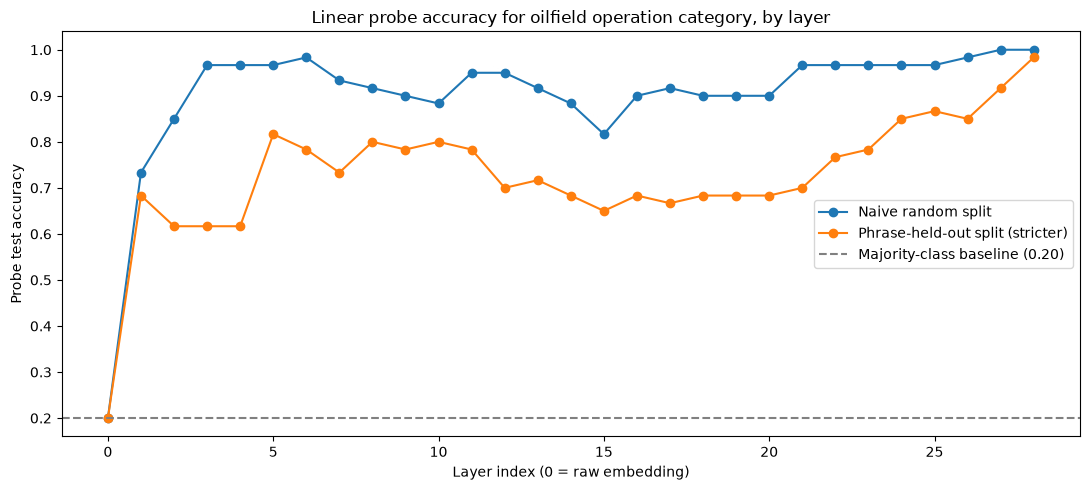

,layer_index,naive_split_accuracy,phrase_heldout_accuracy
0,0,0.200000,0.200000
1,1,0.733333,0.683333
2,2,0.850000,0.616667
3,3,0.966667,0.616667
4,4,0.966667,0.616667
5,5,0.966667,0.816667
6,6,0.983333,0.783333
7,7,0.933333,0.733333
8,8,0.916667,0.800000
9,9,0.900000,0.783333


In [8]:
probing_results = pd.DataFrame({
    "layer_index": range(NUM_FEATURE_SETS),
    "naive_split_accuracy": naive_accuracies,
    "phrase_heldout_accuracy": phrase_heldout_accuracies,
})

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(probing_results["layer_index"], probing_results["naive_split_accuracy"], marker="o", label="Naive random split")
ax.plot(probing_results["layer_index"], probing_results["phrase_heldout_accuracy"], marker="o", label="Phrase-held-out split (stricter)")
ax.axhline(majority_baseline, color="gray", linestyle="--", label=f"Majority-class baseline ({majority_baseline:.2f})")
ax.set_xlabel("Layer index (0 = raw embedding)")
ax.set_ylabel("Probe test accuracy")
ax.set_title("Linear probe accuracy for oilfield operation category, by layer")
ax.legend()
fig.tight_layout()
plt.show()

probing_results


**Interpretation of this real, computed result:** the raw embedding
(layer 0) sits at the majority-class baseline — no linear signal for this
category exists before any transformer processing, consistent with
notebook 3's finding that raw embeddings mostly encode surface form. Both
curves jump sharply at the very first transformer layer. Through the middle
layers, the naive-split curve consistently sits noticeably above the
phrase-held-out curve — a real, measured generalization gap, showing that
part of the naive split's apparent success came from something closer to
memorizing phrase-label pairs than from a category signal that transfers to
genuinely unseen phrasing. That gap narrows by the final few layers, where
both splits converge close to ceiling — plausibly because, by the last
layer, the representation is essentially pre-committed to predicting the
next word, and the next word itself differs sharply and reliably by
category (as notebook 1's context experiments already showed).


## 8. A visual complement: what does the final layer's representation look like?

A 2D projection (via PCA) of the real final-layer representations, colored
by their true category label, as a qualitative complement to the
quantitative probing curve above.


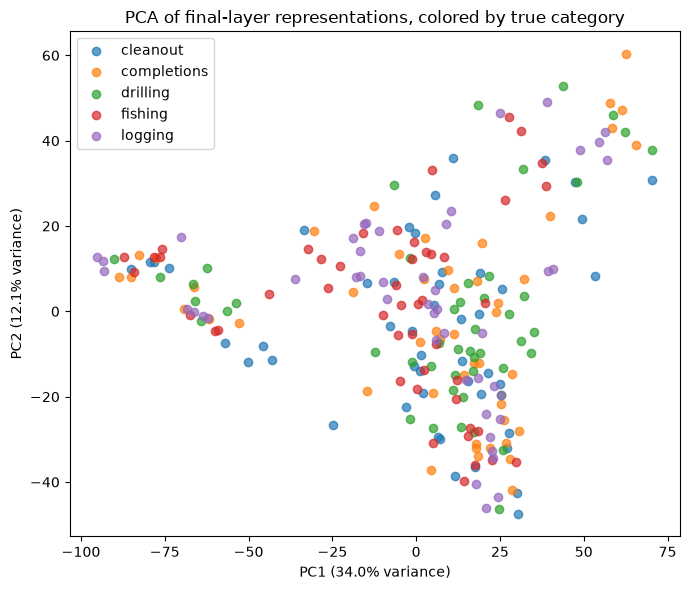

In [9]:
final_layer_features = feature_matrices[-1]
pca = PCA(n_components=2, random_state=SEED)
projected = pca.fit_transform(final_layer_features)

fig, ax = plt.subplots(figsize=(7, 6))
for category in CATEGORIES:
    mask = dataset["category"].to_numpy() == category
    ax.scatter(projected[mask, 0], projected[mask, 1], label=category, alpha=0.7)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title("PCA of final-layer representations, colored by true category")
ax.legend()
fig.tight_layout()
plt.show()


**Interpretation:** if categories form visually distinct clusters
here, that's consistent with the high final-layer probe accuracy above —
but this is only a 2D shadow of a 1536-dimensional space (explaining only
the two variance directions PCA found), so treat it as illustrative, not as
independent proof on its own.


## 9. What probing classifiers can — and cannot — establish

We can honestly say, because we computed and checked it directly above:

- a linear classifier trained on this model's frozen internal
  representations can predict our externally-defined operation category
  far above chance, at every transformer layer we tested
- that accuracy is not uniform: it rises sharply after the first layer, and
  the gap between the easy and strict evaluation narrows by the final
  layers — a real, specific, measured pattern for this dataset and model

We should **not** say:

- that high probe accuracy means the model *uses* this category
  information for its own predictions — a probe only tests whether
  information is linearly *present*, not whether the model's own
  computation *depends* on it. Notebook 5's activation patching, not
  probing, is the right tool for testing use.
- that a probe's success proves the model has a clean, human-like "concept"
  of operation category — the probe is a separately-trained classifier
  finding a linear decision boundary; it does not show us the model's own
  internal decision process
- that a probe's *failure* at some layer proves the information isn't
  present there — we specifically restricted ourselves to a *linear* probe;
  the information could still be present in a form only a nonlinear
  classifier could extract
- that our phrase-held-out split fully solves the shortcut-learning
  problem — it only guards against memorizing the exact phrases we
  reserved for testing; a sufficiently distinctive word (like a tool name
  that's unique to one category) can still let a linear probe generalize
  via a much narrower cue than the full semantic category we intended to
  test
- that these results, from one synthetic dataset built from templates we
  wrote, generalize to real-world oilfield reports with the same accuracy


## 10. Key lessons, and how this notebook fits with 3-5

| Notebook | Question asked | Kind of evidence |
|---|---|---|
| 3: Attention | Which positions does the model weight heavily at this step? | Descriptive, internal, not causal |
| 4: Gradients / occlusion | How sensitive is this specific output to this specific input? | Local approximation / single-substitution causal test |
| 5: Activation patching | Is this specific internal value causally sufficient to restore this specific behavior? | Genuine intervention, but position/layer-specific |
| 6: Probing (this notebook) | Is this externally-defined property linearly present in this representation at all? | Correlational, not causal; about presence, not use |

1. Probing uses labels we define ourselves, not the model's own
   predictions — a genuinely different kind of evidence than notebooks 1-5.
2. Raw input embeddings (layer 0) carried no linear signal for this task;
   the signal appears immediately once transformer processing begins.
3. A naive random split can overstate how well a probe generalizes; testing
   on entirely unseen phrasing revealed a real, measured gap in the middle
   layers.
4. Probing tells you what's linearly *present*; it does not tell you
   whether the model's own behavior *depends* on that information. Those
   are different questions, requiring different tools (compare to notebook
   5's causal interventions).
5. A linear probe's failure doesn't prove information is absent — it might
   only be present in a form a linear classifier can't extract.


## 11. Try your own oilfield sentence

Write a sentence describing one of the five operation categories
(`drilling`, `completions`, `logging`, `cleanout`, `fishing`) in your own
words — not copied from the templates above — and see what the
phrase-held-out-trained probe at the final layer predicts. This uses the
probe already trained in Section 6; no retraining happens here.


In [10]:
user_sentence = "The team recovered the stuck fishing tool after the overshot finally caught it downhole."  # <-- change this line
user_true_category = "fishing"  # <-- your own honest label for the sentence above, for comparison only

user_representations = extract_layer_representations(user_sentence)
final_layer_probe = trained_probes[NUM_FEATURE_SETS - 1]
predicted_index = final_layer_probe.predict([user_representations[-1]])[0]
predicted_probabilities = final_layer_probe.predict_proba([user_representations[-1]])[0]

print(f"Sentence: {user_sentence!r}")
print(f"Your label:      {user_true_category}")
print(f"Probe predicted: {CATEGORIES[predicted_index]}")
print("\nPer-category probability from the probe:")
for category, prob in sorted(zip(CATEGORIES, predicted_probabilities), key=lambda x: -x[1]):
    print(f"  {category:14s} {prob*100:5.1f}%")


Sentence: 'The team recovered the stuck fishing tool after the overshot finally caught it downhole.'
Your label:      fishing
Probe predicted: fishing

Per-category probability from the probe:
  fishing         99.3%
  drilling         0.7%
  logging          0.0%
  cleanout         0.0%
  completions      0.0%


## 12. Optional exercises

1. In Section 11, write a deliberately ambiguous sentence that could
   plausibly belong to two categories (e.g. mentions both a packer and a
   logging tool). What does the probe predict, and how confident is it?
2. In Section 6, change `C=1.0` (the regularization strength) to `C=0.01`
   (much stronger regularization) and re-run Section 7. Does the gap
   between the two splits change?
3. Add a sixth category of your own (e.g. "workover") with its own phrases,
   regenerate the dataset in Section 3, and re-run Sections 5-7.
4. In Section 3, hold out 4 phrases per category instead of 2 (a smaller,
   harder training set). Does the phrase-held-out curve get noticeably
   worse?
5. Pick the single best-performing layer from Section 7's phrase-held-out
   curve. Does it match your intuition for how "deep" semantic category
   information should require going into the network?


## 13. Technical appendix

**Model and environment actually used in this run** (printed live, not
hard-coded):


In [11]:
print(f"Model:                {MODEL_NAME}")
print(f"Device:               {DEVICE}")
print(f"Dtype:                {DTYPE}")
print(f"Transformer layers:   {NUM_LAYERS}")
print(f"Dataset size:         {len(dataset)} examples across {len(CATEGORIES)} categories")
print(f"Python version:       {sys.version.split()[0]}")
print(f"PyTorch version:      {torch.__version__}")
print(f"Transformers version: {transformers.__version__}")
print(f"scikit-learn version: {sklearn.__version__}")
print(f"Random seed:          {SEED}")


Model:                Qwen/Qwen2.5-1.5B-Instruct
Device:               mps
Dtype:                torch.float16
Transformer layers:   28
Dataset size:         240 examples across 5 categories
Python version:       3.12.13
PyTorch version:      2.14.0
Transformers version: 5.16.1
scikit-learn version: 1.9.0
Random seed:          42


**Why logistic regression specifically.** Logistic regression is a
linear classifier with a well-understood decision boundary and built-in L2
regularization (controlled by `C` above), making it the standard,
conservative choice for probing work — the point is to test what's linearly
separable in the representation, not to see how much a powerful classifier
can extract with enough capacity.

**Dataset construction, restated.** All labels in this notebook come from
sentence templates we wrote ourselves, not from the model. This is what
makes probing different from every prior notebook: it needs an external
source of truth, independent of anything the model predicts.
